In [1]:
import pandas as pd
import pickle
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn_quantile import RandomForestQuantileRegressor

In [2]:
with open('../../transformed_event_logs/BPIC_2017_all_train.pickle', 'rb') as f:
    train_data = pickle.load(f)

In [3]:
train_data

,Action_start,org:resource_start,concept:name,EventOrigin_start,EventID_start,lifecycle:transition_start,time:timestamp_start,case:LoanGoal_start,case:ApplicationType_start,case:concept:name,...,intercase_n_3__W_Validate application__suspend_W_Shortened completion __resume_W_Validate application__ate_abort,intercase_n_3__W_Validate application__suspend_W_Shortened completion __resume_W_Validate application__resume,intercase_n_3__W_Validate application__suspend_W_Validate application__ate_abort_W_Assess potential fraud__schedule,intercase_n_3__W_Validate application__suspend_W_Validate application__ate_abort_W_Call incomplete files__schedule,intercase_n_3__W_Validate application__suspend_W_Validate application__ate_abort_W_Validate application__schedule,intercase_n_3__W_Validate application__suspend_W_Validate application__resume_W_Assess potential fraud__schedule,intercase_n_3__W_Validate application__suspend_W_Validate application__resume_W_Call incomplete files__schedule,intercase_n_3__W_Validate application__suspend_W_Validate application__resume_W_Validate application__complete,intercase_n_3__W_Validate application__suspend_W_Validate application__resume_W_Validate application__start,intercase_n_3__W_Validate application__suspend_W_Validate application__resume_W_Validate application__suspend
0,Created,User_112,W_Validate application__schedule,Workflow,Workitem_100000116,schedule,2016-03-02 13:25:52.388000+00:00,Home improvement,Limit raise,Application_1650545424,...,0,0,0,0,0,0,0,0,0,9
1,Released,User_63,W_Call after offers__suspend,Workflow,Workitem_1000010198,suspend,2016-08-20 12:19:22.434000+00:00,Home improvement,New credit,Application_1930272371,...,0,0,0,0,0,0,0,0,0,10
2,Obtained,User_80,W_Call after offers__start,Workflow,Workitem_1000013868,start,2016-10-18 08:54:52.604000+00:00,Car,New credit,Application_1804686886,...,0,0,0,0,0,0,0,0,0,6
3,Released,User_30,W_Call incomplete files__suspend,Workflow,Workitem_1000014801,suspend,2016-11-30 16:55:49.483000+00:00,Not speficied,New credit,Application_655052891,...,0,0,0,0,0,0,0,0,0,12
4,Obtained,User_114,W_Validate application__start,Workflow,Workitem_1000015916,start,2016-01-19 12:58:12.261000+00:00,Car,New credit,Application_704665572,...,0,0,0,0,0,0,0,0,0,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619773,Released,User_112,W_Validate application__suspend,Workflow,Workitem_999946421,suspend,2016-03-07 11:20:38.606000+00:00,Home improvement,New credit,Application_1748541113,...,0,0,0,0,0,0,0,0,0,24
619774,Created,User_116,W_Validate application__schedule,Workflow,Workitem_999950446,schedule,2016-07-15 12:55:25.889000+00:00,Existing loan takeover,New credit,Application_519919221,...,0,0,0,0,0,0,0,0,0,51
619777,Released,User_19,W_Call after offers__suspend,Workflow,Workitem_999988201,suspend,2016-10-04 18:43:06.137000+00:00,Home improvement,New credit,Application_1551324804,...,0,0,0,0,0,0,0,0,0,16
619779,Released,User_51,W_Call after offers__suspend,Workflow,Workitem_999991648,suspend,2016-12-01 20:02:50.875000+00:00,Not speficied,New credit,Application_1000610355,...,0,0,0,0,0,0,0,0,0,12


In [ ]:
x_cols = ['concept:name', 'org:resource_start']

encoded_data = pd.DataFrame()

for col in x_cols:
    codes, uniques = pd.factorize(train_data[col])
    encoded_data[col] = codes

x = encoded_data.astype(float).to_numpy()


y = train_data['duration_seconds']

qrf = RandomForestQuantileRegressor(q=[0.05, 0.50, 0.95])
qrf.fit(x, y)

KeyError: 'Activity_start'

In [ ]:
y_pred_5, y_pred_median, y_pred_95 = qrf.predict(x)
qrf.score(x, y)


np.float64(137305.7342606513)

In [ ]:
x

array([[0., 0.],
       [1., 0.],
       [1., 1.],
       ...,
       [1., 3.],
       [4., 3.],
       [2., 3.]], shape=(13391, 2))

In [ ]:
y_pred_5

array([9.0000000e+00, 2.7495770e+02, 7.0000000e+00, ..., 1.6332951e+01,
       1.0000000e+00, 1.2960124e+06], shape=(13391,), dtype=float32)

In [ ]:
df = pd.concat([train_data, pd.DataFrame({
    'pred_5': y_pred_5,
    'pred_median': y_pred_median,
    'pred_95': y_pred_95
})], axis=1)

In [ ]:
df

,Case ID,Activity_start,Resource_start,Complete Timestamp_start,Variant_start,Variant index_start,Variant.1_start,seriousness_start,customer_start,product_start,...,intercase_n_3__Wait_Take in charge ticket_Resolve ticket,intercase_n_3__Wait_Take in charge ticket_Take in charge ticket,intercase_n_3__Wait_Take in charge ticket_Wait,intercase_n_3__Wait_Wait_Create SW anomaly,intercase_n_3__Wait_Wait_Resolve ticket,intercase_n_3__Wait_Wait_Take in charge ticket,intercase_n_3__Wait_Wait_Wait,pred_5,pred_median,pred_95
0,Case 1,Assign seriousness,Value 1,2012-10-09 14:50:17,Variant 12,12.0,Variant 12,Value 1,Value 1,Value 1,...,0,0,0,0,0,0,0,9.000000e+00,6.242836e+04,1457931.875
1,Case 1,Take in charge ticket,Value 1,2012-10-09 14:51:01,Variant 12,12.0,Variant 12,Value 1,Value 1,Value 1,...,0,0,0,0,0,0,0,2.749577e+02,8.422259e+04,1552669.125
2,Case 1,Take in charge ticket,Value 2,2012-10-12 15:02:56,Variant 12,12.0,Variant 12,Value 1,Value 1,Value 1,...,0,0,1.0,0,0,0,0,7.000000e+00,1.085864e+04,1524876.500
3,Case 1,Resolve ticket,Value 1,2012-10-25 11:54:26,Variant 12,12.0,Variant 12,Value 1,Value 1,Value 1,...,0,0,1.0,0,0,0,0,1.000000e+00,2.520636e+06,4069407.000
4,Case 2,Assign seriousness,Value 4,2012-04-03 08:55:38,Variant 1,1.0,Variant 1,Value 1,Value 2,Value 2,...,0,0,1.0,0,0,0,0,2.374067e+01,1.819746e+04,1912361.500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13383,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.000000e+00,1.085864e+04,1524876.500
13384,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.524628e+05,2.319020e+06,4137989.750
13388,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.633295e+01,1.709818e+04,1704970.000
13389,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,4.284380e+05,2637114.750


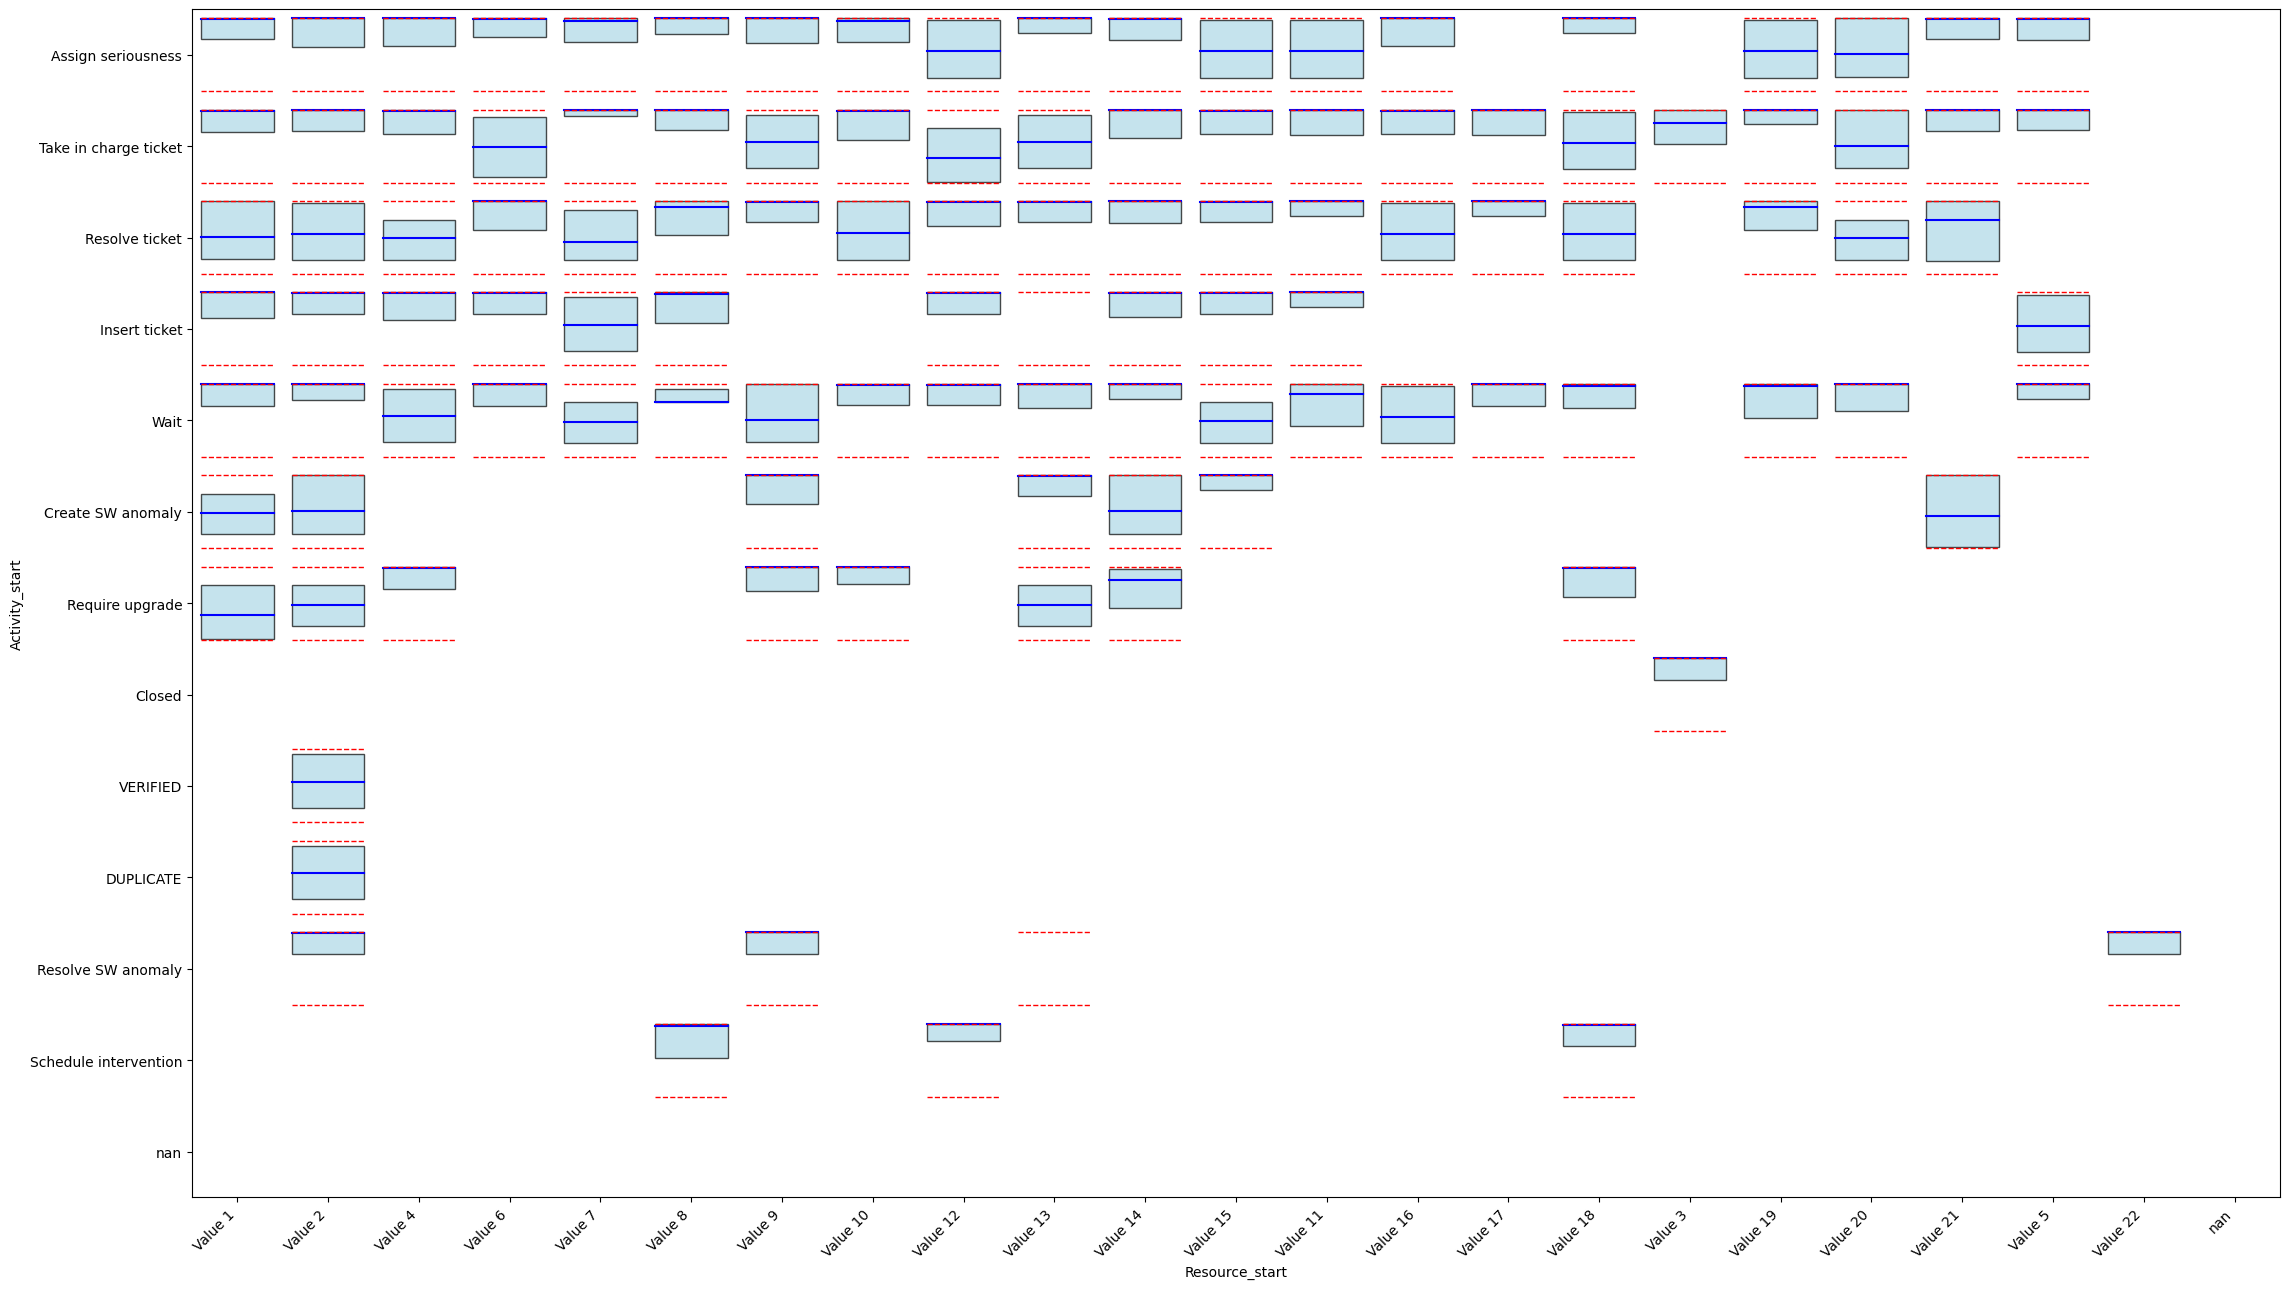

1.0 5.0883415e+06


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd

# Example DataFrame: df with columns Resource_start, Activity_start, pred_5, pred_median, pred_95
catsA = df['Resource_start'].unique()
catsB = df['Activity_start'].unique()
fig, ax = plt.subplots(figsize=(len(catsA) * 1.0, len(catsB) * 1.0))

# Maps for categorical grid positions
x_pos_map = {a: i for i, a in enumerate(catsA)}
y_pos_map = {b: j for j, b in enumerate(catsB)}

# Box width in x-axis units
box_width = 0.8

# Cell height scaling factor (fraction of the 1-unit category spacing)
cell_height = 0.8

# Global min/max for consistent scaling across all cells
vmin = df['pred_5'].min()
vmax = df['pred_95'].max()

for i, a in enumerate(catsA):
    for j, b in enumerate(catsB):
        row = df[(df['Resource_start'] == a) & (df['Activity_start'] == b)]
        if row.empty:
            continue
        q05, q50, q95 = row[['pred_5', 'pred_median', 'pred_95']].values[0]
        x = x_pos_map[a]
        y = y_pos_map[b]
        
        # Define the cell's vertical plotting range (centered at y)
        cell_bottom = y - cell_height / 2
        cell_top = y + cell_height / 2
        
        # Function to map value to y-position within the cell (vmin at bottom, vmax at top)
        def pos(value):
            return cell_bottom + (value - vmin) / (vmax - vmin + 1e-8) * cell_height
        
        # Calculate positions for the box elements
        box_bottom = pos(q05)
        box_height = pos(q95) - pos(q05)
        median_y = pos(q50)
        
        # Draw the box
        ax.add_patch(patches.Rectangle(
            (x - box_width / 2, box_bottom),
            box_width, box_height,
            facecolor='lightblue', edgecolor='black', alpha=0.7
        ))
        
        # Draw median line
        ax.plot([x - box_width / 2, x + box_width / 2], [median_y, median_y], color='blue', lw=1.5)
        
        # Draw horizontal lines for global vmin and vmax in this cell
        ax.plot([x - box_width / 2, x + box_width / 2], [cell_bottom, cell_bottom], color='red', lw=1, linestyle='--')
        ax.plot([x - box_width / 2, x + box_width / 2], [cell_top, cell_top], color='red', lw=1, linestyle='--')

# Set axes
ax.set_xticks(range(len(catsA)))
ax.set_xticklabels(catsA, rotation=45, ha='right')
ax.set_yticks(range(len(catsB)))
ax.set_yticklabels(catsB)
ax.set_xlabel('Resource_start')
ax.set_ylabel('Activity_start')
ax.set_xlim(-0.5, len(catsA) - 0.5)
ax.set_ylim(-0.5, len(catsB) - 0.5)
ax.invert_yaxis()  # optional for matrix-style layout
plt.tight_layout()
plt.show()
print(vmin, vmax)

In [ ]:
vmax / 3600 / 24

np.float32(58.89284)